# Gas Source Estimation with Known Wind

This minimal example estimates the non-negative scalar gas source field

$$
q_\psi(x,y) \geq 0.
$$

The 2D wind field $\mathbf{u}(x,y)$ is assumed to be known. Two neural networks
approximate the gas concentration and source fields:

$$
c_\phi(x,y) \geq 0,
\qquad
q_\psi(x,y) \geq 0.
$$

The networks are coupled through the stationary advection–diffusion equation

$$
-D\Delta c_\phi
+ \mathbf{u}\cdot\nabla c_\phi
- q_\psi
= 0.
$$

During training, the parameters $\phi$ and $\psi$ are adjusted jointly so that

1. the predicted concentration $c_\phi(x_i,y_i)$ matches the $N$ sparse measurements
   $\hat{c}_i(x_i, y_i)$, $i = 0, \ldots, N-1$,
2. the concentration and source fields satisfy the advection–diffusion equation,
3. the concentration satisfies the boundary conditions imposed by the domain
   geometry, and
4. the estimated source is non-negative, sparse, and located in free space.

Both networks are trained using a shared loss function and one Adam optimizer.
This notebook covers only flexible source discovery and does not perform a
subsequent Gaussian refinement.

In [6]:
%cd /app

import matplotlib.pyplot as plt
import numpy as np
import torch

from source_estimation_pinn.environment import OccupancyGrid, WindField
from source_estimation_pinn.estimation import GasSourceConfig, GasSourceEstimator
from source_estimation_pinn.measurements import GasSampleSet

# Synthetic example data
case_dir = "data/example_labyrinth"
true_source = np.array([9.0, 4.5])  # evaluation only, not used for training

torch.manual_seed(12)
occupancy = OccupancyGrid.from_msh_file(
    f"{case_dir}/labyrinth_2d_fine.msh", resolution=0.1
)
wind = WindField.from_csv(f"{case_dir}/wind_gt.csv")
gas_samples = GasSampleSet.from_csv(
    f"{case_dir}/gas_gt9.0_4.5.csv", n=50, random_seed=111
)


/app



## Joint objective

The estimator minimizes

$$
\mathcal L = \mathcal L_\mathrm{data}
+ \mathcal L_\mathrm{AD}
+ \mathcal L_\mathrm{wall}
+ \mathcal L_\mathrm{inflow}
+ \mathcal L_\mathrm{sparse}
+ \mathcal L_\mathrm{nonfree}.
$$

The data term fits the gas measurements. The AD term couples $c_\phi$ and
$q_\psi$. The boundary terms impose zero normal flux at walls and zero
concentration at inflows. The last two terms favor a compact source in free
space. `GasSourceEstimator` handles collocation sampling, derivatives, losses,
and optimizer steps; the important choices remain visible in the config.


In [7]:
config = GasSourceConfig(
    concentration_hidden_layers=3,
    concentration_hidden_dim=64,
    source_hidden_layers=2,
    source_hidden_dim=32,
    diffusion_constant=1e-3,
    lambda_sparse=1e-3,
    lambda_nonfree=1e-1,
    learning_rate=2e-3,
)

estimator = GasSourceEstimator(occupancy=occupancy, wind=wind, config=config)
history = estimator.fit(
    gas_samples,
    steps=3000,
    n_collocation_points=len(occupancy.free_points) // 4,
)


Estimated source: [8.95 4.45]
Distance to truth: 0.07071067811865386


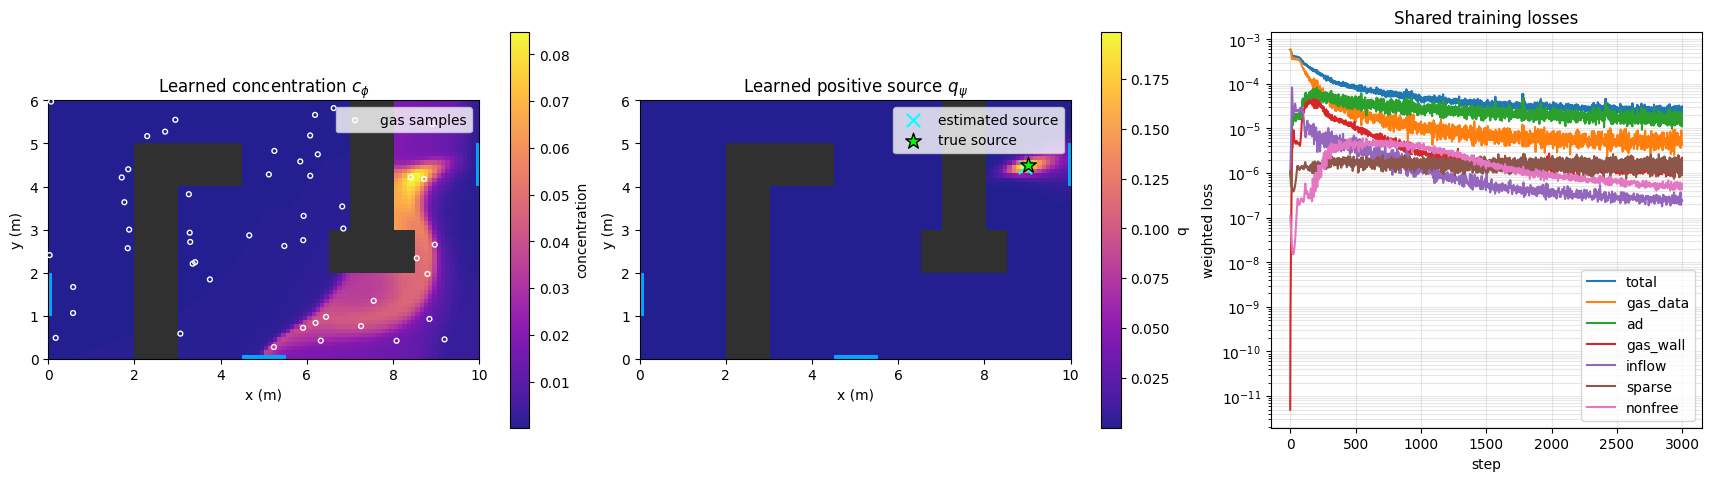

In [8]:
# Evaluate the learned fields on the occupancy grid.
free_points = occupancy.free_points
fields = []
for prediction in (
    estimator.predict_concentration(free_points),
    estimator.predict_source(free_points),
):
    field = np.full(occupancy.occupancy.shape, np.nan)
    field[occupancy.free_mask] = prediction
    fields.append(field)

source_estimate = estimator.get_source_estimate()
extent = [
    occupancy.lower_bound[0], occupancy.upper_bound[0],
    occupancy.lower_bound[1], occupancy.upper_bound[1],
]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.7), constrained_layout=True)

for ax, field, title, label in zip(
    axes[:2],
    fields,
    (r"Learned concentration $c_\phi$", r"Learned positive source $q_\psi$"),
    ("concentration", "q"),
):
    occupancy.plot(ax=ax, title=title)
    ax.get_legend().remove()
    image = ax.imshow(
        field, origin="lower", extent=extent, cmap="plasma",
        interpolation="nearest", alpha=0.9, zorder=2,
    )
    fig.colorbar(image, ax=ax, label=label)

axes[0].scatter(
    *gas_samples.positions.T, s=12, facecolors="none", edgecolors="white",
    label="gas samples", zorder=4,
)
axes[0].legend()
axes[1].scatter(
    *source_estimate, marker="x", s=90, color="cyan",
    label="estimated source", zorder=5,
)
axes[1].scatter(
    *true_source, marker="*", s=140, color="lime", edgecolor="black",
    label="true source", zorder=5,
)
axes[1].legend()

for name, values in history.losses.items():
    values = np.asarray(values)
    axes[2].semilogy(np.where(values > 0, values, np.nan), label=name)
axes[2].set(title="Shared training losses", xlabel="step", ylabel="weighted loss")
axes[2].grid(True, which="both", alpha=0.3)
axes[2].legend()

print("Estimated source:", source_estimate)
print("Distance to truth:", np.linalg.norm(source_estimate - true_source))
plt.show()
